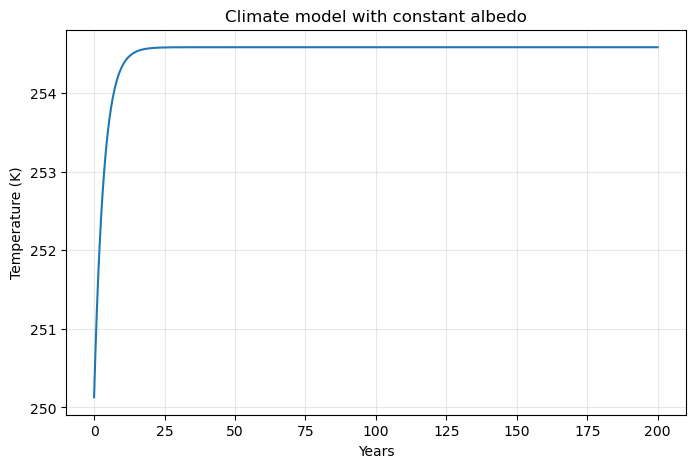

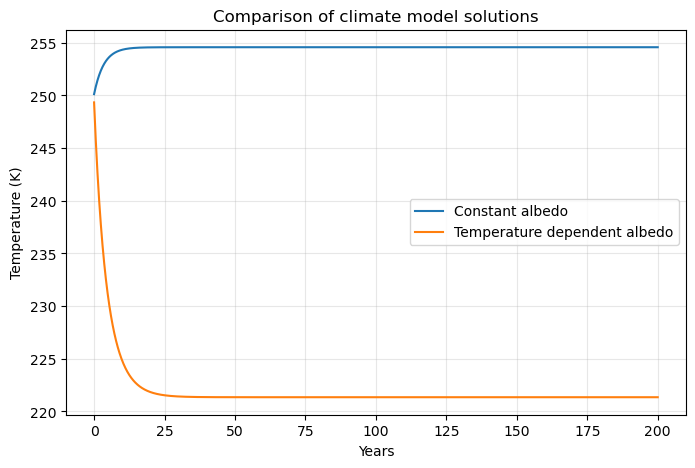

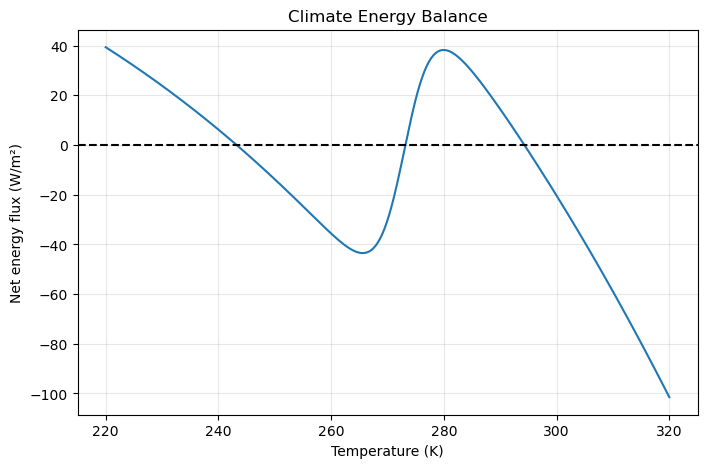

Snowball Earth equilibrium: 243.24 K
Unstable intermediate equilibrium: 273.17 K
Warm climate equilibrium: 294.29 K

Interpretation of the Energy Balance Curve:
- Snowball Earth: low-temperature stable equilibrium
- Intermediate state: unstable equilibrium
- Warm climate Earth: high-temperature stable equilibrium

Approximate equilibrium temperatures:
- Cold stable state: 243.24 K
- Unstable state: 273.17 K
- Warm stable state: 294.29 K


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PHYSICAL CONSTANTS
# =========================
S = 1361.0            # Solar constant (W/m^2)
sigma = 5.67e-8       # Stefan-Boltzmann constant (W m^-2 K^-4)
alpha = 0.3           # Constant planetary albedo
epsilon = 1.0         # Radiative efficiency
C = 4e8               # Effective heat capacity (J m^-2 K^-1)

# =========================
# MODEL 1: CONSTANT ALBEDO
# =========================
def dTdt(T):
    incoming = (1 - alpha) * S / 4
    outgoing = epsilon * sigma * T**4
    return (incoming - outgoing) / C

def rk4_step(T, dt):
    k1 = dTdt(T)
    k2 = dTdt(T + 0.5 * dt * k1)
    k3 = dTdt(T + 0.5 * dt * k2)
    k4 = dTdt(T + dt * k3)
    return T + dt * (k1 + 2*k2 + 2*k3 + k4) / 6

# Time settings
dt = 0.1 * 365 * 24 * 3600   # 0.1 years in seconds
years = 200
steps = int(years / 0.1)

# Initial temperature
T0 = 250.0

# Run constant albedo simulation
T = T0
T_values = []

for i in range(steps):
    T = rk4_step(T, dt)
    T_values.append(T)

time = np.linspace(0, years, steps)

# Plot constant albedo result
plt.figure(figsize=(8, 5))
plt.plot(time, T_values)
plt.xlabel("Years")
plt.ylabel("Temperature (K)")
plt.title("Climate model with constant albedo")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# MODEL 2: ICE-ALBEDO FEEDBACK
# =========================
def albedo_feedback(T):
    return 0.3 + 0.3 * (1 - np.tanh((T - 273) / 10)) / 2

def dTdt_feedback(T):
    a = albedo_feedback(T)
    incoming = (1 - a) * S / 4
    outgoing = epsilon * sigma * T**4
    return (incoming - outgoing) / C

def rk4_feedback(T, dt):
    k1 = dTdt_feedback(T)
    k2 = dTdt_feedback(T + 0.5 * dt * k1)
    k3 = dTdt_feedback(T + 0.5 * dt * k2)
    k4 = dTdt_feedback(T + dt * k3)
    return T + dt * (k1 + 2*k2 + 2*k3 + k4) / 6

# Run feedback simulation
T = T0
T_values_feedback = []

for i in range(steps):
    T = rk4_feedback(T, dt)
    T_values_feedback.append(T)

# Compare both simulations
plt.figure(figsize=(8, 5))
plt.plot(time, T_values, label="Constant albedo")
plt.plot(time, T_values_feedback, label="Temperature dependent albedo")
plt.xlabel("Years")
plt.ylabel("Temperature (K)")
plt.title("Comparison of climate model solutions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# CLIMATE STABILITY AND MULTIPLE EQUILIBRIA
# =========================
epsilon_flux = 0.6

def albedo(T):
    alpha_cold = 0.65
    alpha_warm = 0.25
    T_transition = 273
    width = 5
    return alpha_warm + (alpha_cold - alpha_warm) * (1 - np.tanh((T - T_transition) / width)) / 2

def energy_flux(T):
    a = albedo(T)
    incoming = (1 - a) * S / 4
    outgoing = epsilon_flux * sigma * T**4
    return incoming - outgoing

T_curve = np.linspace(220, 320, 500)
F = energy_flux(T_curve)

# Plot energy balance curve
plt.figure(figsize=(8, 5))
plt.plot(T_curve, F)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Temperature (K)")
plt.ylabel("Net energy flux (W/m²)")
plt.title("Climate Energy Balance")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# ESTIMATE EQUILIBRIUM TEMPERATURES
# =========================
sign_changes = np.where(np.sign(F[:-1]) != np.sign(F[1:]))[0]
roots = []

for i in sign_changes:
    T1, T2 = T_curve[i], T_curve[i + 1]
    F1, F2 = F[i], F[i + 1]
    root = T1 - F1 * (T2 - T1) / (F2 - F1)
    roots.append(root)

print(f"Snowball Earth equilibrium: {roots[0]:.2f} K")
print(f"Unstable intermediate equilibrium: {roots[1]:.2f} K")
print(f"Warm climate equilibrium: {roots[2]:.2f} K")

# =========================
# INTERPRETATION
# =========================
print("\nInterpretation of the Energy Balance Curve:")
print("- Snowball Earth: low-temperature stable equilibrium")
print("- Intermediate state: unstable equilibrium")
print("- Warm climate Earth: high-temperature stable equilibrium")
print("\nApproximate equilibrium temperatures:")
print(f"- Cold stable state: {roots[0]:.2f} K")
print(f"- Unstable state: {roots[1]:.2f} K")
print(f"- Warm stable state: {roots[2]:.2f} K")